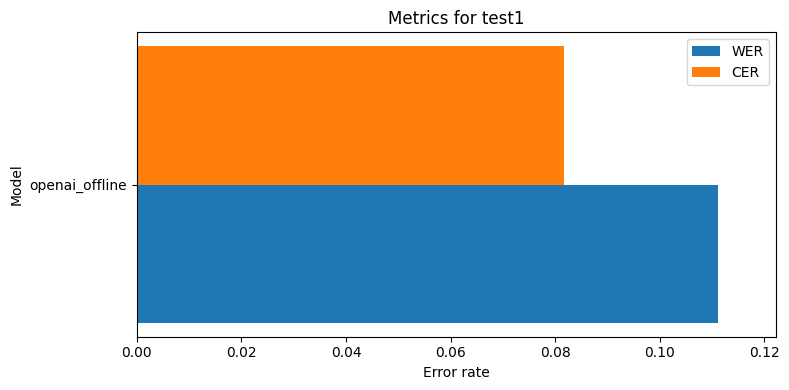

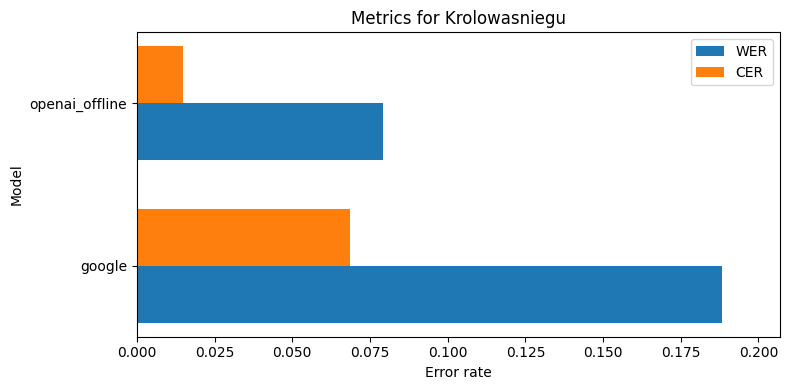

In [8]:
# Multi-model transcription and metrics UI
import os
import html
from pathlib import Path
from IPython.display import display
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np

# Local project imports
from transcribe import amazon_stt, google_stt, ms_azure_stt, whisperOffline
from remove_punctuation import strip_punctuation_text
from jiwer import wer, cer, process_words

# Prepare folders and file lists
base_dir = Path('.')  # notebook located in backend/ so '.' is backend/
audio_exts = ['.wav', '.mp3', '.m4a']
audio_files = [f.name for f in base_dir.iterdir() if f.suffix.lower() in audio_exts]
text_files = [f.name for f in base_dir.iterdir() if f.suffix.lower() == '.txt']

# Widgets: choose audio file from existing files or provide path
audio_dropdown = widgets.Dropdown(options=['--choose--'] + audio_files, description='Recording:')
audio_path_text = widgets.Text(placeholder='Or paste full path to audio file', description='Audio path:', layout=widgets.Layout(width='600px'))

# Reference text selection
ref_dropdown = widgets.Dropdown(options=['--choose--'] + text_files, description='Reference:')
ref_textarea = widgets.Textarea(placeholder='Or paste reference text here', description='Ref text:', layout=widgets.Layout(width='600px', height='120px'))

# Model toggles (checkboxes)
models = {
    'amazon': widgets.Checkbox(False, description='Amazon'),
    'google': widgets.Checkbox(False, description='Google'),
    'azure': widgets.Checkbox(False, description='Azure'),
    'openai_online': widgets.Checkbox(False, description='OpenAI online'),
    'openai_offline': widgets.Checkbox(False, description='OpenAI offline (local)')
}

run_button = widgets.Button(description='Run selected models', button_style='primary')
output = widgets.Output(layout={'border': '1px solid gray'})

# Display widgets for resolved reference and model outputs
reference_preview = widgets.Textarea(
    value='',
    description='Reference (normalized):',
    disabled=True,
    layout=widgets.Layout(width='100%', height='140px')
)
model_outputs_container = widgets.VBox([])

ui = widgets.VBox([
    audio_dropdown,
    audio_path_text,
    ref_dropdown,
    ref_textarea,
    widgets.HBox(list(models.values())),
    run_button,
    output,
    widgets.HTML('<b>Reference text used for metrics (no punctuation, lowercase)</b>'),
    reference_preview,
    widgets.HTML('<b>Transcriptions by selected model (no punctuation, lowercase)</b>'),
    model_outputs_container
])
display(ui)

# Helper to resolve audio and reference paths
def resolve_audio_path():
    if audio_path_text.value.strip():
        return audio_path_text.value.strip()
    if audio_dropdown.value and audio_dropdown.value != '--choose--':
        return str(base_dir / audio_dropdown.value)
    return None

def resolve_reference():
    # If textarea used, write to a temp file and return path
    if ref_textarea.value.strip():
        temp_dir = base_dir / 'temp_refs'
        temp_dir.mkdir(exist_ok=True)
        p = temp_dir / f'ref_{int(os.times()[4])}.txt'
        p.write_text(ref_textarea.value, encoding='utf-8')
        return str(p)
    if ref_dropdown.value and ref_dropdown.value != '--choose--':
        return str(base_dir / ref_dropdown.value)
    return None

def normalize_for_metrics(text: str) -> str:
    return strip_punctuation_text(text).lower()

def _chunk_type_to_class(chunk_type):
    normalized = str(chunk_type).lower()
    if normalized in ('equal', 'hit', 'correct'):
        return 'eq'
    if normalized in ('substitute', 'substitution', 'replace'):
        return 'sub'
    if normalized in ('delete', 'deletion'):
        return 'del'
    if normalized in ('insert', 'insertion'):
        return 'ins'
    return 'eq'

def _tokens_to_spans(tokens, css_class):
    if not tokens:
        return ''
    return ''.join(
        f"<span class='token {css_class}'>{html.escape(token)}</span> " for token in tokens
    )

def build_colored_diff_html(reference_text, hypothesis_text, model_name):
    try:
        processed = process_words(reference_text, hypothesis_text)

        ref_line = []
        hyp_line = []

        for sent_idx, chunks in enumerate(processed.alignments):
            ref_tokens = processed.references[sent_idx]
            hyp_tokens = processed.hypotheses[sent_idx]

            for chunk in chunks:
                css_class = _chunk_type_to_class(chunk.type)
                ref_part = ref_tokens[chunk.ref_start_idx:chunk.ref_end_idx]
                hyp_part = hyp_tokens[chunk.hyp_start_idx:chunk.hyp_end_idx]

                if css_class == 'del':
                    ref_line.append(_tokens_to_spans(ref_part, 'del'))
                    hyp_line.append("<span class='token gap'>∅</span> ")
                elif css_class == 'ins':
                    ref_line.append("<span class='token gap'>∅</span> ")
                    hyp_line.append(_tokens_to_spans(hyp_part, 'ins'))
                elif css_class == 'sub':
                    ref_line.append(_tokens_to_spans(ref_part, 'sub-ref'))
                    hyp_line.append(_tokens_to_spans(hyp_part, 'sub-hyp'))
                else:
                    ref_line.append(_tokens_to_spans(ref_part, 'eq'))
                    hyp_line.append(_tokens_to_spans(hyp_part, 'eq'))

            ref_line.append('<br/>')
            hyp_line.append('<br/>')

        html_block = f"""
        <style>
          .diff-wrap {{
            border: 1px solid #ddd;
            border-radius: 8px;
            padding: 10px;
            margin: 8px 0 14px 0;
            font-family: ui-monospace, SFMono-Regular, Menlo, Consolas, monospace;
            font-size: 12px;
            line-height: 1.7;
            white-space: normal;
            word-break: break-word;
          }}
          .diff-title {{ font-weight: 700; margin-bottom: 6px; }}
          .diff-row-label {{ font-weight: 700; color: #333; margin-right: 8px; }}
          .token {{
            display: inline-block;
            margin: 1px 2px;
            padding: 0 4px;
            border-radius: 4px;
          }}
          .eq {{ background: #f5f5f5; color: #222; }}
          .sub-ref {{ background: #ffe1e1; color: #8a1c1c; }}
          .sub-hyp {{ background: #fff1cc; color: #7a5b00; }}
          .del {{ background: #ffd6d6; color: #8a1c1c; text-decoration: line-through; }}
          .ins {{ background: #d9f8d9; color: #1d6f1d; font-weight: 600; }}
          .gap {{ background: #ececec; color: #888; }}
          .legend {{ margin-top: 8px; color: #555; font-size: 11px; }}
        </style>
        <div class='diff-wrap'>
          <div class='diff-title'>Różnice względem referencji — {html.escape(model_name)}</div>
          <div><span class='diff-row-label'>REF:</span>{''.join(ref_line)}</div>
          <div><span class='diff-row-label'>HYP:</span>{''.join(hyp_line)}</div>
          <div class='legend'>
            <span class='token sub-ref'>zamiana (ref)</span>
            <span class='token sub-hyp'>zamiana (model)</span>
            <span class='token del'>usunięte</span>
            <span class='token ins'>dodane</span>
          </div>
        </div>
        """
        return html_block
    except Exception as e:
        return f"<div style='color:#b00020;'>Nie udało się wygenerować diff HTML dla {html.escape(model_name)}: {html.escape(str(e))}</div>"

# Run transcription per model. Each returns transcribed text (string) or empty string on failure
def run_transcription_for_model(model_key, audio_path):
    try:
        if model_key == 'amazon':
            return amazon_stt.transcribe_file(audio_path) or ''
        if model_key == 'google':
            resp = google_stt.transcribe_file(audio_path)
            # Extract transcripts if response provided
            try:
                texts = [r.alternatives[0].transcript for r in resp.results]
                return ' '.join(texts)
            except Exception:
                return ''
        if model_key == 'azure':
            return ms_azure_stt.transcribe_file(audio_path) or ''
        if model_key == 'openai_offline':
            client = whisperOffline.LocalWhisperClient(model_size='small')
            res = client.transcribe(audio_path)
            return res.get('text','')
        if model_key == 'openai_online':
            # Try to call OpenAI API similarly to openAiWhisper.py but with given audio_path
            try:
                from openai import OpenAI
                # load credentials if present (optional)
                client = OpenAI()
                with open(audio_path, 'rb') as af:
                    transcription = client.audio.transcriptions.create(model='gpt-4o-transcribe', file=af)
                return getattr(transcription, 'text', '') or transcription.get('text', '')
            except Exception as e:
                print('OpenAI online transcription failed:', e)
                return ''
    except Exception as e:
        print(f'Error running model {model_key}:', e)
        return ''

# When run button is clicked
def on_run_clicked(_):
    with output:
        output.clear_output()
        reference_preview.value = ''
        model_outputs_container.children = tuple()

        ap = resolve_audio_path()
        ref = resolve_reference()
        if not ap:
            print('Please select or provide an audio file path')
            return
        if not ref:
            print('Please select or provide a reference text')
            return

        try:
            reference_text_raw = Path(ref).read_text(encoding='utf-8')
        except Exception as e:
            print('Failed to read reference text:', e)
            return

        reference_text = normalize_for_metrics(reference_text_raw)
        reference_preview.value = reference_text

        print('Audio:', ap)
        print('Reference:', ref)
        print('Metrics mode: normalized (no punctuation, lowercase)')

        results = {}
        trans_dir = base_dir / 'transcriptions'
        trans_dir.mkdir(exist_ok=True)
        basename = Path(ap).stem

        model_output_widgets = []

        for key, chk in models.items():
            if chk.value:
                print(f'Running {key}...')
                txt_raw = run_transcription_for_model(key, ap)
                txt = normalize_for_metrics(txt_raw)

                out_path = trans_dir / f'{key}_{basename}.txt'
                out_path.write_text(txt, encoding='utf-8')

                model_output_widgets.append(
                    widgets.VBox([
                        widgets.Textarea(
                            value=txt if txt else '[empty transcription]',
                            description=f'{key}:',
                            disabled=True,
                            layout=widgets.Layout(width='100%', height='110px')
                        ),
                        widgets.HTML(value=build_colored_diff_html(reference_text, txt, key))
                    ])
                )

                # compute numeric metrics for plotting
                try:
                    w = wer(reference_text, txt)
                    c = cer(reference_text, txt)

                    print(f'Metrics for model: {key} (normalized text)')
                    print(f'WER: {w}')
                    print(f'CER: {c}')
                except Exception as e:
                    print('Failed computing metrics for', key, e)
                    w, c = None, None
                results[key] = {'wer': w, 'cer': c}

        if model_output_widgets:
            model_outputs_container.children = tuple(model_output_widgets)
        else:
            model_outputs_container.children = (widgets.Label('No model outputs were produced.'),)

        # After loop, plot results for selected models
        if results:
            keys = list(results.keys())
            wers = [results[k]['wer'] if results[k]['wer'] is not None else np.nan for k in keys]
            cers = [results[k]['cer'] if results[k]['cer'] is not None else np.nan for k in keys]

            fig, ax = plt.subplots(figsize=(8, 4))
            y = np.arange(len(keys))
            bar_h = 0.35

            ax.barh(y - bar_h / 2, wers, height=bar_h, label='WER')
            ax.barh(y + bar_h / 2, cers, height=bar_h, label='CER')

            ax.set_yticks(y)
            ax.set_yticklabels(keys)
            max_val = max([v for v in wers + cers if not np.isnan(v)] + [0.01])
            ax.set_xlim(0, max_val * 1.1)
            ax.set_xlabel('Error rate')
            ax.set_ylabel('Model')
            ax.set_title(f'Metrics for {basename}')
            ax.legend()
            plt.tight_layout()
            display(fig)
        else:
            print('No models were selected or no results produced')

run_button.on_click(on_run_clicked)